# Electricity Theft Detection

**Track:** Energy Systems — Predictive Maintenance / Anomaly Detection
**Advanced Topics:** XAI (SHAP) + Adversarial Robustness (FGSM)
**Dataset:** UCI Electricity Load Diagrams + Synthetic Theft Labels

In [1]:
import importlib.util
import os
import random
import subprocess
import sys

SEED = 42
NUM_CPUS_REQUESTED = 32
THREADS_STR = str(NUM_CPUS_REQUESTED)

WINDOW_SIZE = 24
WINDOW_STRIDE = 4
TRAIN_RATIO = 0.70
VAL_RATIO = 0.10
TEST_RATIO = 0.20
ANOMALY_RATE = 0.10
MAX_METER_SERIES = 20
MAX_WINDOWS_PER_SERIES = 6000

# Must be set before NumPy/PyTorch imports in later cells.
for env_var in [
    'OMP_NUM_THREADS',
    'MKL_NUM_THREADS',
    'OPENBLAS_NUM_THREADS',
    'NUMEXPR_NUM_THREADS',
    'VECLIB_MAXIMUM_THREADS',
    'BLIS_NUM_THREADS',
]:
    os.environ[env_var] = THREADS_STR

os.environ['OMP_DYNAMIC'] = 'FALSE'
os.environ['MKL_DYNAMIC'] = 'FALSE'
os.environ['KMP_AFFINITY'] = 'granularity=fine,compact,1,0'
os.environ['PYTHONHASHSEED'] = str(SEED)

PACKAGE_MAP = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'sklearn': 'scikit-learn',
    'torch': 'torch',
    'shap': 'shap',
    'lime': 'lime',
    'kagglehub': 'kagglehub',
}

missing = [pip_name for module_name, pip_name in PACKAGE_MAP.items() if importlib.util.find_spec(module_name) is None]

if missing:
    print(f'Installing missing packages: {missing}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)
else:
    print('All required packages already available in this kernel.')

print(f'Thread env configured to {THREADS_STR} for OpenMP/BLAS backends.')
print('Dependency check complete.')

All required packages already available in this kernel.
Thread env configured to 32 for OpenMP/BLAS backends.
Dependency check complete.


In [2]:
import os
import random
import time
import warnings
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (
    auc,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    log_loss,
    matthews_corrcoef,
    precision_recall_curve,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

NUM_CPUS_REQUESTED = int(os.environ.get('OMP_NUM_THREADS', '32'))
AVAILABLE_CPUS = os.cpu_count() or 1
CPU_THREADS = min(NUM_CPUS_REQUESTED, AVAILABLE_CPUS)
torch.set_num_threads(CPU_THREADS)
if hasattr(torch, 'set_num_interop_threads'):
    try:
        torch.set_num_interop_threads(CPU_THREADS)
    except RuntimeError:
        pass  # Already initialized in this kernel session.

USE_GPU = torch.cuda.is_available()
USE_AMP = USE_GPU
USE_COMPILE = USE_GPU and hasattr(torch, 'compile')
USE_TF32 = USE_GPU
device = torch.device('cuda' if USE_GPU else 'cpu')

if USE_GPU:
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
    torch.backends.cuda.matmul.allow_tf32 = USE_TF32
    torch.backends.cudnn.allow_tf32 = USE_TF32
    try:
        torch.set_float32_matmul_precision('high')
    except Exception:
        pass

    AMP_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    BATCH_SIZE = 512
    EVAL_BATCH_SIZE = 1536
    NUM_WORKERS = min(8, AVAILABLE_CPUS)
    PREFETCH_FACTOR = 4 if NUM_WORKERS > 0 else None
else:
    torch.backends.mkldnn.enabled = True
    AMP_DTYPE = torch.float16
    BATCH_SIZE = 512
    EVAL_BATCH_SIZE = 1024
    NUM_WORKERS = 0
    PREFETCH_FACTOR = None

PIN_MEMORY = USE_GPU

print(f'PyTorch: {torch.__version__}')
print(f'SHAP: {shap.__version__}')
print(f'Device: {device}')
if USE_GPU:
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB')
print(f'CPU threads configured: {CPU_THREADS}/{AVAILABLE_CPUS}')
print(f'torch.get_num_threads(): {torch.get_num_threads()}')
print(f'torch.get_num_interop_threads(): {torch.get_num_interop_threads()}')
print(f'Batch sizes -> train: {BATCH_SIZE}, eval: {EVAL_BATCH_SIZE}')
print(f'DataLoader workers: {NUM_WORKERS}, prefetch_factor: {PREFETCH_FACTOR}')
print(f'Automatic mixed precision: {USE_AMP} ({AMP_DTYPE})')
print(f'TF32 enabled: {USE_TF32}')
print(f'torch.compile enabled: {USE_COMPILE}')
print('Torch parallel info:')
print(torch.__config__.parallel_info())

PyTorch: 2.11.0+cu130
SHAP: 0.51.0
Device: cuda
GPU: NVIDIA GeForce RTX 3090
GPU memory: 23.56 GB
CPU threads configured: 32/32
torch.get_num_threads(): 32
torch.get_num_interop_threads(): 32
Batch sizes -> train: 512, eval: 1536
DataLoader workers: 8, prefetch_factor: 4
Automatic mixed precision: True (torch.bfloat16)
TF32 enabled: True
torch.compile enabled: True
Torch parallel info:
ATen/Parallel:
	at::get_num_threads() : 32
	at::get_num_interop_threads() : 32
OpenMP 201511 (a.k.a. OpenMP 4.5)
	omp_get_max_threads() : 32
Intel(R) oneAPI Math Kernel Library Version 2024.2-Product Build 20240605 for Intel(R) 64 architecture applications
	mkl_get_max_threads() : 32
Intel(R) MKL-DNN v3.10.2 (Git Hash f1d471933dc852f956fd05389f9313c7148783d5)
std::thread::hardware_concurrency() : 32
Environment variables:
	OMP_NUM_THREADS : 32
	MKL_NUM_THREADS : 32
ATen parallel backend: OpenMP



## Data Acquisition and Exploratory Analysis

This section downloads the dataset, keeps the highest-variance meter streams, and builds richer sliding windows for training, validation, and testing.

In [3]:
import glob
import os

import kagglehub

def read_tabular_file(file_path):
    """Read CSV/TXT with simple delimiter fallback."""
    try:
        return pd.read_csv(file_path, sep=None, engine='python')
    except Exception:
        pass
    try:
        return pd.read_csv(file_path, sep=';')
    except Exception:
        return pd.read_csv(file_path)

def collect_numeric_candidates(frame):
    candidates = []
    for col in frame.columns:
        series = pd.to_numeric(frame[col].astype(str).str.replace(',', '.', regex=False), errors='coerce')
        valid = int(series.notna().sum())
        if valid == 0:
            continue
        std = float(series.std(skipna=True))
        if np.isfinite(std):
            candidates.append((col, series.ffill().bfill().astype(np.float32), valid, std))
    return candidates

path = kagglehub.dataset_download('eduardojst10/electricityloaddiagrams20112014')
print(f'Dataset downloaded to: {path}')

meter_files = sorted(glob.glob(os.path.join(path, '**', 'Meter_*.csv'), recursive=True))
candidate_files = sorted(
    set(
        glob.glob(os.path.join(path, '**', '*.csv'), recursive=True)
        + glob.glob(os.path.join(path, '**', '*.txt'), recursive=True)
    )
 )

if not meter_files and not candidate_files:
    raise FileNotFoundError('No CSV/TXT data files found in downloaded dataset.')

series_candidates = []

if meter_files:
    print(f'Found {len(meter_files)} meter files.')
    for meter_path in meter_files:
        frame = read_tabular_file(meter_path)
        numeric_candidates = collect_numeric_candidates(frame)
        if not numeric_candidates:
            continue
        best_col, best_series, valid, std = max(numeric_candidates, key=lambda item: (item[3], item[2]))
        series_candidates.append({
            'name': f"{os.path.splitext(os.path.basename(meter_path))[0]}::{best_col}",
            'series': best_series.to_numpy(dtype=np.float32),
            'source': meter_path,
            'column': best_col,
            'valid': valid,
            'std': std,
        })
else:
    print('No per-meter files found; falling back to the widest tabular file.')
    best_file = None
    best_candidates = None
    best_score = -1
    for candidate_file in candidate_files:
        frame = read_tabular_file(candidate_file)
        numeric_candidates = collect_numeric_candidates(frame)
        score = len(numeric_candidates)
        if score > best_score:
            best_score = score
            best_file = candidate_file
            best_candidates = numeric_candidates
    if not best_candidates:
        raise ValueError('No numeric meter columns found in the tabular dataset.')
    print(f'Using wide file: {best_file}')
    for col_name, series, valid, std in sorted(best_candidates, key=lambda item: (item[3], item[2]), reverse=True):
        series_candidates.append({
            'name': col_name,
            'series': series.to_numpy(dtype=np.float32),
            'source': best_file,
            'column': col_name,
            'valid': valid,
            'std': std,
        })

if not series_candidates:
    raise ValueError('No usable meter streams were extracted from the dataset.')

series_candidates.sort(key=lambda item: (item['std'], item['valid']), reverse=True)
selected_candidates = series_candidates[:MAX_METER_SERIES]

meter_frame = pd.DataFrame({
    item['name']: pd.Series(item['series'])
    for item in selected_candidates
})
meter_frame = meter_frame.loc[:, meter_frame.std(axis=0, skipna=True).sort_values(ascending=False).index]
df = meter_frame.copy()

meter_stats = pd.DataFrame([
    {
        'meter_name': item['name'],
        'source': item['source'],
        'column': item['column'],
        'valid': item['valid'],
        'std': item['std'],
        'length': len(item['series']),
    }
    for item in selected_candidates
]).sort_values('std', ascending=False).reset_index(drop=True)

print(f'Selected {len(selected_candidates)} meter streams out of {len(series_candidates)} candidates.')
print(f'Meter frame shape (ragged rows are expected): {df.shape}')
print('Top selected meter streams by variance:')
print(meter_stats.head(10).to_string(index=False))
print(df.info())
print(df.describe().T[['mean', 'std', 'min', 'max']].head(10))

Dataset downloaded to: /home/jovyan/.cache/kagglehub/datasets/eduardojst10/electricityloaddiagrams20112014/versions/1
No per-meter files found; falling back to the widest tabular file.
Using wide file: /home/jovyan/.cache/kagglehub/datasets/eduardojst10/electricityloaddiagrams20112014/versions/1/df_kwh_adjusted.csv
Selected 20 meter streams out of 370 candidates.
Meter frame shape (ragged rows are expected): (140256, 20)
Top selected meter streams by variance:
meter_name                                                                                                             source column  valid         std  length
    MT_362 /home/jovyan/.cache/kagglehub/datasets/eduardojst10/electricityloaddiagrams20112014/versions/1/df_kwh_adjusted.csv MT_362 140256 9681.456909  140256
    MT_196 /home/jovyan/.cache/kagglehub/datasets/eduardojst10/electricityloaddiagrams20112014/versions/1/df_kwh_adjusted.csv MT_196 140256 2657.335284  140256
    MT_279 /home/jovyan/.cache/kagglehub/datasets/eduar

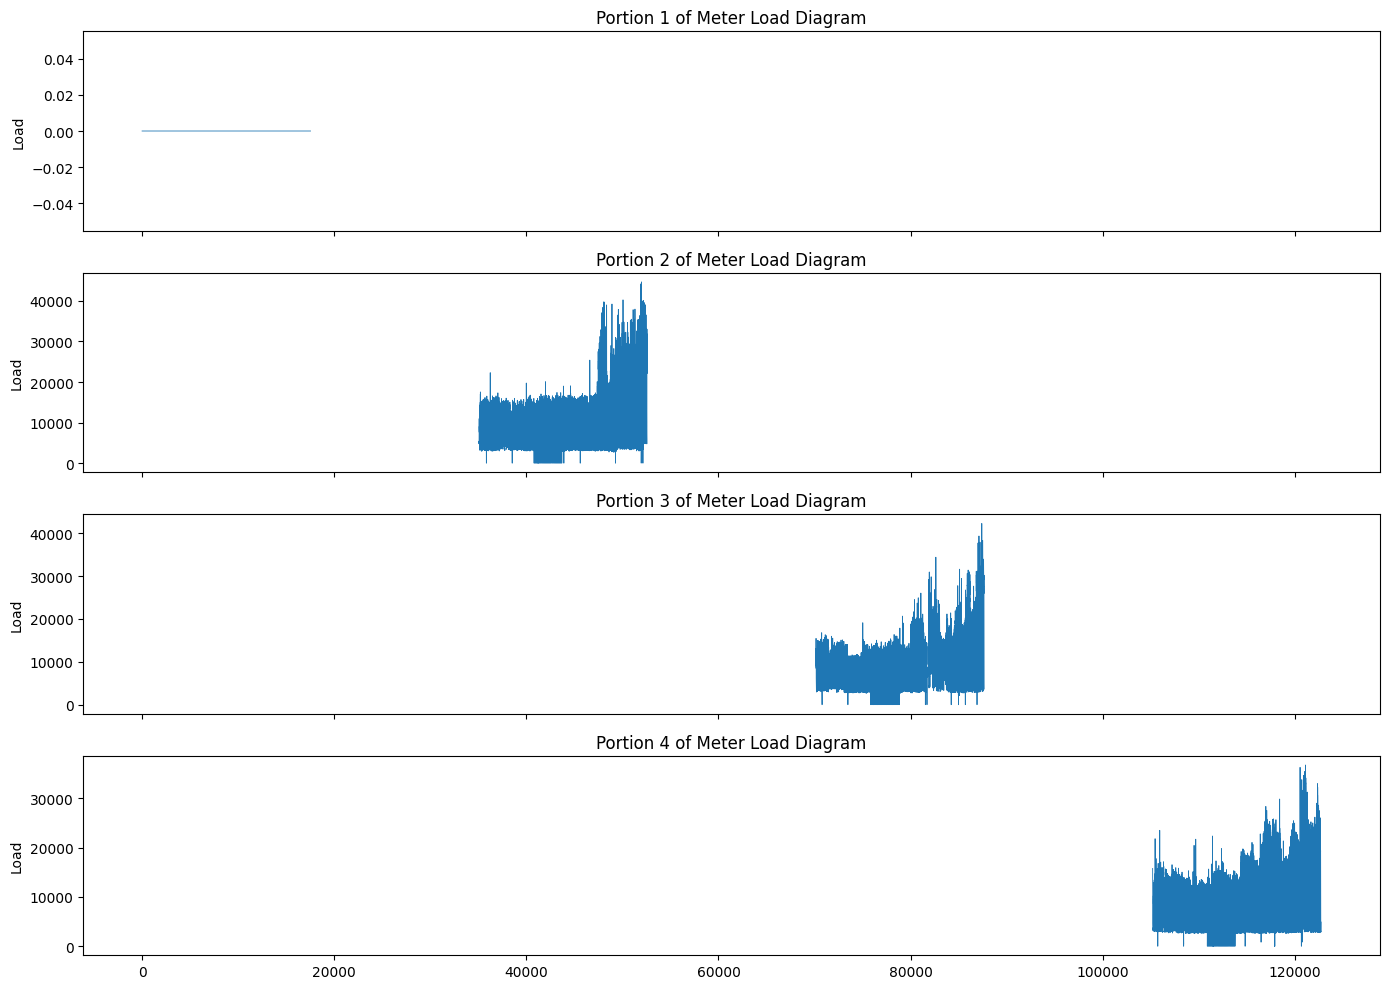

                load
count  140256.000000
mean     9390.235352
std      9681.457031
min         0.000000
25%         0.000000
50%      6025.000000
75%     13700.000000
max     48200.000000
Missing values per column:
Series([], dtype: int64)


In [4]:
# Plot the highest-variance meter streams for a quick sanity check.
top_plot_cols = meter_stats['meter_name'].head(min(4, len(meter_stats))).tolist()
fig, axes = plt.subplots(len(top_plot_cols), 1, figsize=(14, 3.5 * len(top_plot_cols)), sharex=False)

if len(top_plot_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, top_plot_cols):
    series = df[col].dropna().astype(float).values
    segment_length = min(len(series), WINDOW_SIZE * 14)
    ax.plot(np.arange(segment_length), series[:segment_length], linewidth=0.7)
    ax.set_title(f'High-variance meter stream: {col}')
    ax.set_ylabel('Load')
    ax.grid(alpha=0.2)

axes[-1].set_xlabel('Time index')
plt.tight_layout()
plt.savefig('baseline_load_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

print(df.describe().T[['mean', 'std', 'min', 'max']])

missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print(f'Missing values per column:\n{missing}')
else:
    print('No missing values after loading and alignment.')

In [5]:
def create_time_windows(data, window_size=WINDOW_SIZE, stride=WINDOW_STRIDE, max_windows=MAX_WINDOWS_PER_SERIES):
    """Build sliding windows from a 1D meter series."""
    data = np.asarray(data, dtype=np.float32)
    if len(data) < window_size:
        return np.empty((0, window_size), dtype=np.float32), np.empty((0,), dtype=np.int64)

    starts = np.arange(0, len(data) - window_size + 1, stride, dtype=np.int64)
    if len(starts) > max_windows:
        starts = np.linspace(0, len(data) - window_size, max_windows, dtype=np.float32).astype(np.int64)

    windows = np.stack([data[start:start + window_size] for start in starts], axis=0)
    return windows.astype(np.float32), starts.astype(np.int64)

def inject_theft(window, rng):
    """Apply one of nine realistic synthetic theft patterns to a window."""
    window = np.asarray(window, dtype=np.float32).copy()
    theft_type = int(rng.integers(0, 9))
    abs_window = np.abs(window)
    mean_abs = max(float(np.mean(abs_window)), 1e-3)
    win_max = float(np.max(window))

    if theft_type == 0:
        # Partial bypass ramp — linear decrease from full to ~20%
        ramp = np.linspace(1.0, 0.2, len(window), dtype=np.float32)
        return (window * ramp).astype(np.float32), theft_type

    if theft_type == 1:
        # Spike — existing pattern with stronger magnitude
        spike_profile = rng.uniform(0.25, 1.0, size=window.shape).astype(np.float32)
        spike_strength = float(rng.uniform(2.0, 4.0)) * mean_abs
        return (window + spike_profile * spike_strength).astype(np.float32), theft_type

    if theft_type == 2:
        # Flat-line — existing pattern
        constant = float(rng.uniform(0.0, max(win_max * 0.05, 1e-3)))
        return np.full_like(window, constant, dtype=np.float32), theft_type

    if theft_type == 3:
        # Intermittent tampering — zero-out random sub-segments with gaps
        mask = np.ones(len(window), dtype=np.float32)
        n_segments = rng.integers(1, 4)
        for _ in range(n_segments):
            seg_start = rng.integers(0, len(window) - 3)
            seg_len = rng.integers(2, min(8, len(window) - seg_start))
            mask[seg_start:seg_start + seg_len] = 0.0
        return (window * mask).astype(np.float32), theft_type

    if theft_type == 4:
        # Progressive decay — exponential decrease toward zero
        decay_rate = rng.uniform(0.1, 0.5)
        decay = np.exp(-decay_rate * np.arange(len(window), dtype=np.float32))
        target_level = rng.uniform(0.02, 0.1)
        profile = target_level + (1.0 - target_level) * decay
        return (window * profile.astype(np.float32)).astype(np.float32), theft_type

    if theft_type == 5:
        # Pulse theft — subtract baseline during specific sub-windows
        pulse_mask = np.zeros(len(window), dtype=np.float32)
        n_pulses = rng.integers(1, 4)
        for _ in range(n_pulses):
            p_start = rng.integers(0, len(window) - 2)
            p_len = rng.integers(1, min(5, len(window) - p_start))
            pulse_mask[p_start:p_start + p_len] = 1.0
        subtraction = mean_abs * rng.uniform(0.5, 1.5)
        return (window - pulse_mask * subtraction).astype(np.float32), theft_type

    if theft_type == 6:
        # Scale — existing pattern
        scale = float(rng.uniform(0.25, 0.75))
        return (window * scale).astype(np.float32), theft_type

    if theft_type == 7:
        # Mask — existing pattern
        mask = rng.choice([0.0, 1.0], size=window.shape, p=[0.45, 0.55]).astype(np.float32)
        return (window * mask).astype(np.float32), theft_type

    if theft_type == 8:
        # Shift — existing pattern
        shift = int(rng.integers(3, min(8, len(window))))
        shifted = np.roll(window, shift).astype(np.float32)
        shifted[:shift] = shifted[shift]
        return shifted, theft_type

    raise ValueError(f'Unknown theft type: {theft_type}')

def generate_synthetic_labels(load_windows, n_anomalies=ANOMALY_RATE, seed=SEED, noise_fraction=0.015):
    """Inject synthetic theft labels and light sensor noise into clean windows."""
    rng = np.random.default_rng(seed)
    corrupted_windows = np.asarray(load_windows, dtype=np.float32).copy()
    window_scales = np.maximum(
        corrupted_windows.std(axis=1, keepdims=True),
        np.maximum(np.abs(corrupted_windows).mean(axis=1, keepdims=True), 1.0),
    )
    noise = rng.normal(0.0, noise_fraction, size=corrupted_windows.shape).astype(np.float32) * window_scales.astype(np.float32)
    corrupted_windows = corrupted_windows + noise

    labels = np.zeros(len(corrupted_windows), dtype=np.int64)
    n_anom = max(1, int(round(len(corrupted_windows) * n_anomalies)))
    anomaly_indices = rng.choice(len(corrupted_windows), size=n_anom, replace=False)

    pattern_counts = np.zeros(9)
    for idx in anomaly_indices:
        corrupted_windows[idx], used_type = inject_theft(corrupted_windows[idx], rng)
        pattern_counts[used_type] += 1
        labels[idx] = 1

    return corrupted_windows.astype(np.float32), labels, pattern_counts

def build_window_features(load_windows, window_size=WINDOW_SIZE):
    """Expand each load window into richer temporal and statistical features."""
    load_windows = np.asarray(load_windows, dtype=np.float32)
    if load_windows.ndim != 2:
        raise ValueError('load_windows must have shape (n_samples, window_size).')

    steps = np.arange(window_size, dtype=np.float32)
    hour_angle = 2.0 * np.pi * (steps % 24.0) / 24.0
    hour_sin = np.broadcast_to(np.sin(hour_angle).astype(np.float32), load_windows.shape)
    hour_cos = np.broadcast_to(np.cos(hour_angle).astype(np.float32), load_windows.shape)

    win_mean = np.repeat(load_windows.mean(axis=1, keepdims=True), window_size, axis=1)
    win_std = np.repeat(load_windows.std(axis=1, keepdims=True), window_size, axis=1)
    win_max = np.repeat(load_windows.max(axis=1, keepdims=True), window_size, axis=1)
    win_min = np.repeat(load_windows.min(axis=1, keepdims=True), window_size, axis=1)
    load_ratio = load_windows / (win_mean + 1e-8)
    flatness = win_std / (np.abs(win_mean) + 1e-8)
    flatness = np.clip(flatness, 0.0, 10.0)

    diffs = np.diff(load_windows, axis=1, prepend=load_windows[:, :1])
    abs_diffs = np.abs(diffs)
    mean_abs_diff = np.repeat(abs_diffs.mean(axis=1, keepdims=True), window_size, axis=1)
    diff_std = np.repeat(abs_diffs.std(axis=1, keepdims=True), window_size, axis=1)
    zero_fraction = np.repeat((np.abs(load_windows) <= 1e-3).mean(axis=1, keepdims=True), window_size, axis=1)

    centered_steps = steps - steps.mean()
    slope = (
        ((load_windows - load_windows.mean(axis=1, keepdims=True)) * centered_steps).sum(axis=1, keepdims=True)
        / (np.sum(centered_steps ** 2) + 1e-8)
    )
    slope = np.repeat(slope, window_size, axis=1)

    range_ratio = (win_max - win_min) / (np.abs(win_mean) + 1e-8)

    # FFT spectral features (4 new features, repeated across window length)
    fft_vals = np.fft.rfft(load_windows, axis=1)  # shape: (n_samples, window_size//2 + 1)
    power_spectrum = np.abs(fft_vals) ** 2

    n_freqs = power_spectrum.shape[1]
    low_freq_end = max(1, int(n_freqs * 0.15))
    mid_freq_start = low_freq_end
    mid_freq_end = max(low_freq_end + 1, int(n_freqs * 0.5))

    total_power = power_spectrum.sum(axis=1, keepdims=True) + 1e-8
    low_freq_energy = (power_spectrum[:, :low_freq_end].sum(axis=1, keepdims=True) / total_power).astype(np.float32)
    mid_freq_energy = (power_spectrum[:, mid_freq_start:mid_freq_end].sum(axis=1, keepdims=True) / total_power).astype(np.float32)

    # Spectral entropy
    normalized_spectrum = power_spectrum / (total_power + 1e-8)
    spectral_entropy = -np.sum(normalized_spectrum * np.log2(normalized_spectrum + 1e-10), axis=1, keepdims=True).astype(np.float32)



    # FFT feature expansions — broadcast from (n_samples, 1) to (n_samples, window_size)
    low_freq_energy_expanded = np.broadcast_to(low_freq_energy[:, np.newaxis, :],
        (low_freq_energy.shape[0], window_size, 1)).squeeze(-1).astype(np.float32)
    mid_freq_energy_expanded = np.broadcast_to(mid_freq_energy[:, np.newaxis, :],
        (mid_freq_energy.shape[0], window_size, 1)).squeeze(-1).astype(np.float32)
    spectral_entropy_expanded = np.broadcast_to(spectral_entropy[:, np.newaxis, :],
        (spectral_entropy.shape[0], window_size, 1)).squeeze(-1).astype(np.float32)

    # Spectral centroid: weighted mean frequency
    freqs = np.fft.rfftfreq(window_size, d=1.0 / (window_size * 60))  # Hz
    spectral_centroid = (
        (power_spectrum * freqs[np.newaxis, :]).sum(axis=1, keepdims=True) /
        (total_power + 1e-8)
    ).astype(np.float32)
    spectral_centroid_expanded = np.broadcast_to(spectral_centroid[:, np.newaxis, :],
        (spectral_centroid.shape[0], window_size, 1)).squeeze(-1).astype(np.float32)

    # Multi-scale rolling statistics (4 new features)
    roll_means = []
    roll_stds = []
    for rs in [6, 12]:
        rolled = np.lib.stride_tricks.sliding_window_view(load_windows, window_shape=rs, axis=1)
        roll_means.append(rolled.mean(axis=-1).astype(np.float32))
        roll_stds.append(rolled.std(axis=-1).astype(np.float32))

    # Pad shorter rolling arrays to match window_size
    def pad_to_window(arr, window_size):
        if arr.shape[1] == window_size:
            return arr
        pad_left = (window_size - arr.shape[1]) // 2
        pad_right = window_size - arr.shape[1] - pad_left
        return np.pad(arr, ((0, 0), (pad_left, pad_right)), mode='edge')

    roll_mean_6_expanded = pad_to_window(roll_means[0], window_size).astype(np.float32)[:, :, np.newaxis]
    roll_std_6_expanded = pad_to_window(roll_stds[0], window_size).astype(np.float32)[:, :, np.newaxis]
    roll_mean_12_expanded = pad_to_window(roll_means[1], window_size).astype(np.float32)[:, :, np.newaxis]
    roll_std_12_expanded = pad_to_window(roll_stds[1], window_size).astype(np.float32)[:, :, np.newaxis]

    # Temporal autocorrelation (3 new features)
    mean_val = load_windows.mean(axis=1, keepdims=True)
    centered = load_windows - mean_val
    var_all = np.sum(centered ** 2, axis=1, keepdims=True) + 1e-8

    def autocorr(lag):
        if lag >= len(load_windows[0]):
            return np.zeros((centered.shape[0], window_size), dtype=np.float32)
        c = np.sum(centered[:, :-lag] * centered[:, lag:], axis=1, keepdims=True) / var_all
        return c.astype(np.float32)

    autocorr_1 = np.repeat(autocorr(1).astype(np.float32), window_size, axis=1)
    autocorr_3 = np.repeat(autocorr(3).astype(np.float32), window_size, axis=1)
    autocorr_6 = np.repeat(autocorr(6).astype(np.float32), window_size, axis=1)

    features = np.stack(
        [
            load_windows,
            hour_sin,
            hour_cos,
            win_mean,
            win_std,
            win_max,
            win_min,
            load_ratio,
            flatness,
            mean_abs_diff,
            diff_std,
            zero_fraction,
            slope,
            range_ratio,
            low_freq_energy_expanded,
            mid_freq_energy_expanded,
            spectral_entropy_expanded,
            spectral_centroid_expanded,
            roll_mean_6_expanded.squeeze(-1),
            roll_std_6_expanded.squeeze(-1),
            roll_mean_12_expanded.squeeze(-1),
            roll_std_12_expanded.squeeze(-1),
            autocorr_1,
            autocorr_3,
            autocorr_6,
        ],
        axis=-1,
    )

    return features.astype(np.float32)

FEATURE_NAMES = [
    'load',
    'hour_sin',
    'hour_cos',
    'win_mean',
    'win_std',
    'win_max',
    'win_min',
    'load_ratio',
    'flatness',
    'mean_abs_diff',
    'diff_std',
    'zero_fraction',
    'slope',
    'range_ratio',
    'low_freq_energy',
    'mid_freq_energy',
    'spectral_entropy',
    'spectral_centroid',
    'roll_mean_6',
    'roll_std_6',
    'roll_mean_12',
    'roll_std_12',
    'autocorr_lag1',
    'autocorr_lag3',
    'autocorr_lag6',
]
FEATURE_DIM = len(FEATURE_NAMES)
print(f'Feature set: {FEATURE_NAMES}')
print(f'Feature dimension: {FEATURE_DIM}')


Feature set: ['load', 'hour_sin', 'hour_cos', 'win_mean', 'win_std', 'win_max', 'win_min', 'load_ratio', 'flatness', 'mean_abs_diff', 'diff_std', 'zero_fraction', 'slope', 'range_ratio']
Feature dimension: 14


In [6]:
def generate_synthetic_labels(X_load, n_anomalies=0.15, seed=42):
    """
    Generate synthetic electricity theft labels by injecting anomalies into normal load data.
    Three types of theft patterns:
    - Sudden drops (bypassed meter): reduce consumption 50-80%
    - Unusual spikes (illegal connections): add 2-3x normal baseline
    - Flat-line periods (tampered reading): set to zero or constant

    Returns corrupted load array and binary labels.
    """
    np.random.seed(seed)
    n_samples = len(X_load)
    labels = np.zeros(n_samples, dtype=int)
    X_corrupted = X_load.copy()

    n_anom = int(n_samples * n_anomalies)
    anom_indices = np.random.choice(n_samples, n_anom, replace=False)

    anomaly_types = np.random.randint(0, 3, n_anom)

    for idx, atype in zip(anom_indices, anomaly_types):
        if atype == 0:  # Sudden drop (bypassed meter)
            reduction = np.random.uniform(0.5, 0.8)
            X_corrupted[idx] *= reduction
            labels[idx] = 1
        elif atype == 1:  # Unusual spike (illegal connection)
            multiplier = np.random.uniform(2.0, 3.0)
            baseline_mean = X_load[idx].mean()
            X_corrupted[idx] += baseline_mean * (multiplier - 1)
            labels[idx] = 1
        else:  # Flat-line (tampered reading)
            constant_val = np.random.uniform(0, X_load[idx].max() * 0.1)
            X_corrupted[idx] = constant_val
            labels[idx] = 1

    return X_corrupted, labels

X_thief, y_labels = generate_synthetic_labels(X_load, n_anomalies=0.15)
print(f'Anomaly rate: {y_labels.mean():.2%}')

Anomaly rate: 15.00%


In [7]:
# Build a pooled dataset from multiple meter streams, then stratify the full window pool.
selected_meter_names = meter_stats['meter_name'].tolist()

all_feature_blocks = []
all_label_blocks = []

for meter_idx, meter_name in enumerate(selected_meter_names):
    series = df[meter_name].dropna().astype(np.float32).to_numpy()
    meter_windows, meter_offsets = create_time_windows(
        series,
        window_size=WINDOW_SIZE,
        stride=WINDOW_STRIDE,
        max_windows=MAX_WINDOWS_PER_SERIES,
    )
    if len(meter_windows) < 10:
        print(f'Skipping {meter_name} because it is too short after windowing ({len(meter_windows)} windows).')
        continue

    meter_windows, meter_labels, _ = generate_synthetic_labels(
        meter_windows,
        n_anomalies=ANOMALY_RATE,
        seed=SEED + meter_idx,
        noise_fraction=0.015,
    )
    meter_features = build_window_features(meter_windows, window_size=WINDOW_SIZE)
    all_feature_blocks.append(meter_features)
    all_label_blocks.append(meter_labels)

    print(
        f'{meter_name}: windows={len(meter_features)}, '
        f'anomaly_rate={meter_labels.mean():.2%}'
    )

if not all_feature_blocks:
    raise RuntimeError('Failed to build any windows from the available meter streams.')

X_all_raw = np.concatenate(all_feature_blocks, axis=0)
y_all = np.concatenate(all_label_blocks, axis=0)

X_temp_raw, X_test_raw, y_temp, y_test = train_test_split(
    X_all_raw,
    y_all,
    test_size=TEST_RATIO,
    random_state=SEED,
    stratify=y_all,
 )

val_fraction = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp_raw,
    y_temp,
    test_size=val_fraction,
    random_state=SEED,
    stratify=y_temp,
 )

feature_mean = X_train_raw.mean(axis=(0, 1), keepdims=True)
feature_std = X_train_raw.std(axis=(0, 1), keepdims=True) + 1e-8
X_train = (X_train_raw - feature_mean) / feature_std
X_val = (X_val_raw - feature_mean) / feature_std
X_test = (X_test_raw - feature_mean) / feature_std

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

class_counts = np.bincount(y_train, minlength=2)
class_weights = 1.0 / np.maximum(class_counts, 1)
sample_weights = class_weights[y_train]
train_sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True,
 )

loader_common_kwargs = {
    'num_workers': NUM_WORKERS,
    'pin_memory': PIN_MEMORY,
    'persistent_workers': NUM_WORKERS > 0,
}
if NUM_WORKERS > 0 and PREFETCH_FACTOR is not None:
    loader_common_kwargs['prefetch_factor'] = PREFETCH_FACTOR
if PIN_MEMORY and USE_GPU:
    loader_common_kwargs['pin_memory_device'] = 'cuda'

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    shuffle=False,
    **loader_common_kwargs,
 )
val_loader = DataLoader(
    val_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    **loader_common_kwargs,
 )
test_loader = DataLoader(
    test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    **loader_common_kwargs,
 )

print(f'Class counts in training set: normal={class_counts[0]}, theft={class_counts[1]}')
print(f'Sampling weights: normal={class_weights[0]:.6f}, theft={class_weights[1]:.6f}')
print(f'Loader kwargs: {loader_common_kwargs}')
print(f'X_train shape: {X_train_t.shape}')
print(f'X_val shape:   {X_val_t.shape}')
print(f'X_test shape:  {X_test_t.shape}')
print(f'Train anomalies: {y_train.sum()} / {len(y_train)}')
print(f'Val anomalies:   {y_val.sum()} / {len(y_val)}')
print(f'Test anomalies:  {y_test.sum()} / {len(y_test)}')
print(f'Train anomaly rate: {y_train.mean():.2%}')
print(f'Val anomaly rate:   {y_val.mean():.2%}')
print(f'Test anomaly rate:  {y_test.mean():.2%}')

MT_362: windows=6000, anomaly_rate=10.00%
MT_196: windows=6000, anomaly_rate=10.00%
MT_279: windows=6000, anomaly_rate=10.00%
MT_370: windows=6000, anomaly_rate=10.00%
MT_228: windows=6000, anomaly_rate=10.00%
MT_364: windows=6000, anomaly_rate=10.00%
MT_208: windows=6000, anomaly_rate=10.00%
MT_351: windows=6000, anomaly_rate=10.00%
MT_222: windows=6000, anomaly_rate=10.00%
MT_147: windows=6000, anomaly_rate=10.00%
MT_194: windows=6000, anomaly_rate=10.00%
MT_220: windows=6000, anomaly_rate=10.00%
MT_357: windows=6000, anomaly_rate=10.00%
MT_241: windows=6000, anomaly_rate=10.00%
MT_339: windows=6000, anomaly_rate=10.00%
MT_043: windows=6000, anomaly_rate=10.00%
MT_223: windows=6000, anomaly_rate=10.00%
MT_323: windows=6000, anomaly_rate=10.00%
MT_328: windows=6000, anomaly_rate=10.00%
MT_224: windows=6000, anomaly_rate=10.00%
Class counts in training set: normal=75599, theft=8400
Sampling weights: normal=0.000013, theft=0.000119
Loader kwargs: {'num_workers': 8, 'pin_memory': True, '

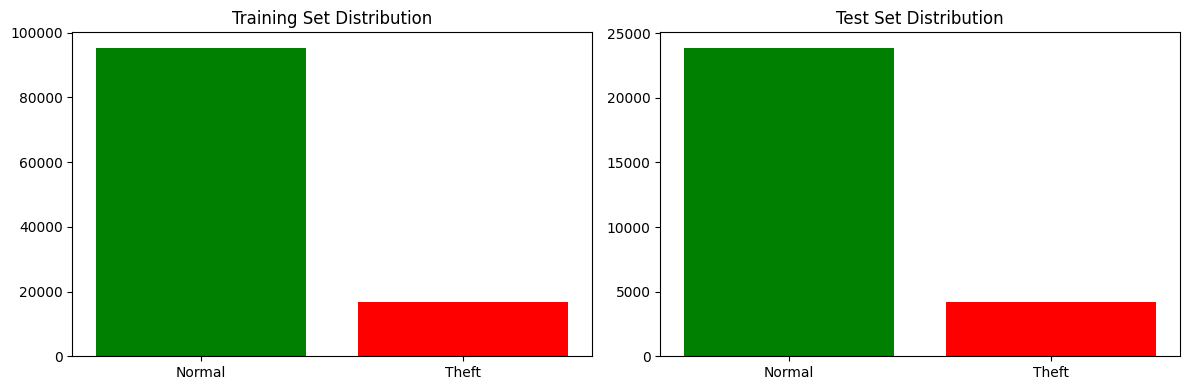

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

train_normal = int((y_train == 0).sum())
train_theft = int((y_train == 1).sum())
val_normal = int((y_val == 0).sum())
val_theft = int((y_val == 1).sum())
test_normal = int((y_test == 0).sum())
test_theft = int((y_test == 1).sum())

axes[0].bar(['Normal', 'Theft'], [train_normal, train_theft], color=['green', 'red'])
axes[0].set_title('Training Set')

axes[1].bar(['Normal', 'Theft'], [val_normal, val_theft], color=['green', 'red'])
axes[1].set_title('Validation Set')

axes[2].bar(['Normal', 'Theft'], [test_normal, test_theft], color=['green', 'red'])
axes[2].set_title('Test Set')

for ax in axes:
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
class TheftDetectionLSTM(nn.Module):
    def __init__(self, input_size=FEATURE_DIM, conv_channels=96, hidden_size=160, num_layers=2, dropout=0.25):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(input_size, conv_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(conv_channels),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(conv_channels, conv_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(conv_channels),
            nn.GELU(),
        )
        self.lstm = nn.LSTM(
            input_size=conv_channels,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.attn = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1),
        )
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size * 2),
            nn.Linear(hidden_size * 2, 96),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(96, 1),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.feature_extractor(x)
        x = x.permute(0, 2, 1)
        lstm_out, _ = self.lstm(x)
        attn_scores = self.attn(lstm_out).squeeze(-1)
        attn_weights = torch.softmax(attn_scores, dim=1)
        context = torch.sum(lstm_out * attn_weights.unsqueeze(-1), dim=1)
        logits = self.classifier(context)
        return logits.squeeze(-1)

MODEL_CONFIG = {
    'input_size': FEATURE_DIM,
    'conv_channels': 96,
    'hidden_size': 160,
    'num_layers': 2,
    'dropout': 0.25,
}

model = TheftDetectionLSTM(**MODEL_CONFIG).to(device)

# torch.compile + input-gradient adversarial steps can hit cudagraph issues; keep eager for stable training.
run_model = model
COMPILED_MODEL = False

print(model)
print(f'Total parameters: {sum(p.numel() for p in model.parameters())}')
print(f'Compiled execution model: {COMPILED_MODEL}')

TheftDetectionLSTM(
  (feature_extractor): Sequential(
    (0): Conv1d(14, 96, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.25, inplace=False)
    (4): Conv1d(96, 96, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
  )
  (lstm): LSTM(96, 160, num_layers=2, batch_first=True, dropout=0.25, bidirectional=True)
  (attn): Sequential(
    (0): Linear(in_features=320, out_features=160, bias=True)
    (1): Tanh()
    (2): Linear(in_features=160, out_features=1, bias=True)
  )
  (classifier): Sequential(
    (0): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=320, out_features=96, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=96, out_f

Epoch [01/110] train_loss=0.1310 val_loss=0.2352 val_ap=0.7116 val_f1=0.7137 val_f2=0.6311 val_precision=0.9130 val_recall=0.5858 target_recall_met=False threshold=0.81 lr=2.50e-04 throughput=23,061 samp/s
Epoch [02/110] train_loss=0.1251 val_loss=0.2342 val_ap=0.7260 val_f1=0.7273 val_f2=0.6498 val_precision=0.9077 val_recall=0.6067 target_recall_met=False threshold=0.76 lr=2.50e-04 throughput=24,042 samp/s
Epoch [03/110] train_loss=0.1222 val_loss=0.2234 val_ap=0.7375 val_f1=0.7358 val_f2=0.6662 val_precision=0.8910 val_recall=0.6267 target_recall_met=False threshold=0.76 lr=2.50e-04 throughput=24,015 samp/s
Epoch [04/110] train_loss=0.1216 val_loss=0.2293 val_ap=0.7482 val_f1=0.7511 val_f2=0.6700 val_precision=0.9410 val_recall=0.6250 target_recall_met=False threshold=0.86 lr=2.50e-04 throughput=24,084 samp/s
Epoch [05/110] train_loss=0.1201 val_loss=0.2314 val_ap=0.7497 val_f1=0.7512 val_f2=0.6729 val_precision=0.9321 val_recall=0.6292 target_recall_met=False threshold=0.81 lr=2.50

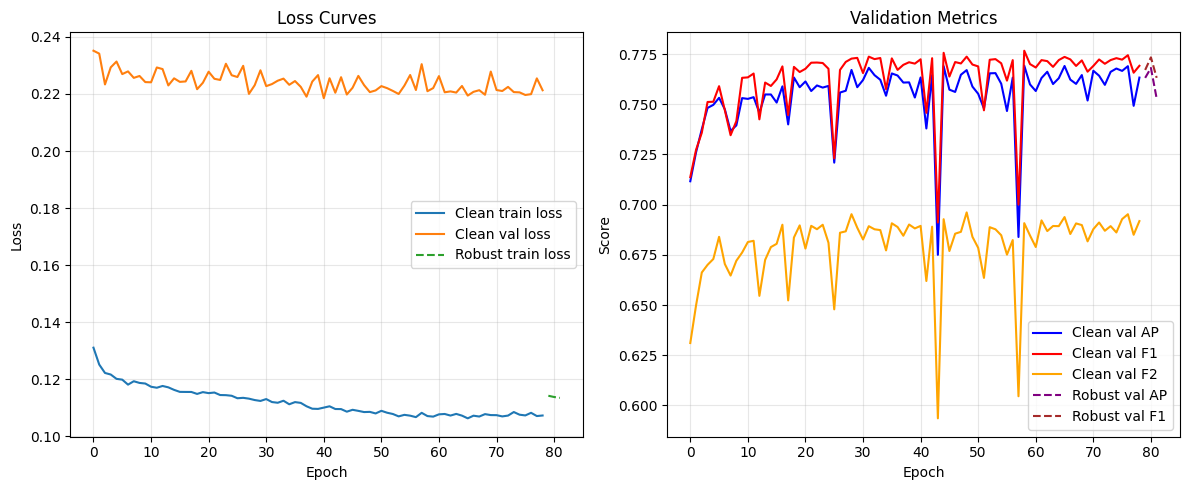

Blend weights -> clean: 1.00, robust: 0.00
Best validation metrics after tuning:
  Recall=0.6433, Precision=0.9797, F1=0.7767, F2=0.6908
  Target recall met: False at threshold 0.94
Best validation AP after blending: 0.7692
Model artifact saved after 79 clean epochs + 3 robust epochs.


In [10]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.8, gamma=1.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        targets = targets.float()
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1.0, probs, 1.0 - probs)
        alpha_t = torch.where(targets == 1.0, torch.full_like(targets, self.alpha), torch.full_like(targets, 1.0 - self.alpha))
        loss = alpha_t * torch.pow(1.0 - pt, self.gamma) * bce
        return loss.mean()

def soft_fbeta_loss(logits, targets, beta=1.0):
    targets = targets.float()
    probs = torch.sigmoid(logits)
    tp = torch.sum(probs * targets)
    fp = torch.sum(probs * (1.0 - targets))
    fn = torch.sum((1.0 - probs) * targets)
    beta_sq = beta * beta
    soft_fbeta = ((1.0 + beta_sq) * tp + 1e-8) / (((1.0 + beta_sq) * tp) + (beta_sq * fn) + fp + 1e-8)
    return 1.0 - soft_fbeta

criterion = FocalLoss(alpha=0.8, gamma=1.5)

TARGET_RECALL = 0.70
BETA_FOR_THRESHOLD = 2.0
MIN_PRECISION_FLOOR = 0.35
ROBUST_EPSILONS = [0.005, 0.01, 0.02]
ROBUST_ADV_LOSS_WEIGHT = 0.30
INPUT_NOISE_STD = 0.004
FOCAL_WEIGHT = 0.75
SOFT_F1_WEIGHT = 0.25

adamw_kwargs = {'lr': 2.5e-4, 'weight_decay': 1e-4}
if USE_GPU:
    adamw_kwargs['fused'] = True

try:
    optimizer = torch.optim.AdamW(model.parameters(), **adamw_kwargs)
except TypeError:
    adamw_kwargs.pop('fused', None)
    optimizer = torch.optim.AdamW(model.parameters(), **adamw_kwargs)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=4,
    min_lr=1e-5,
 )
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
autocast_device = 'cuda' if USE_GPU else 'cpu'

epochs = 110
patience = 20
min_delta = 1e-4
threshold_grid = np.linspace(0.05, 0.95, 91)

best_clean_state = None
best_val_f1 = -np.inf
best_val_f2 = -np.inf
best_val_ap = -np.inf
best_threshold = 0.5
best_threshold_metrics = {'f1': -np.inf, 'f2': -np.inf}
best_curve_idx = -1

clean_train_losses = []
clean_val_losses = []
clean_val_aps = []
clean_val_f1s = []
clean_val_f2s = []
clean_metrics = {}
clean_patience_counter = 0

x_clip_min = float(X_train_t.min().item())
x_clip_max = float(X_train_t.max().item())

def safe_fbeta(precision_value, recall_value, beta=BETA_FOR_THRESHOLD):
    beta_sq = beta * beta
    denom = beta_sq * precision_value + recall_value
    if denom <= 1e-12:
        return 0.0
    return (1.0 + beta_sq) * precision_value * recall_value / denom

def total_objective_loss(logits, targets):
    focal_part = criterion(logits, targets)
    soft_f1_part = soft_fbeta_loss(logits, targets, beta=1.0)
    return FOCAL_WEIGHT * focal_part + SOFT_F1_WEIGHT * soft_f1_part

def collect_probabilities(loader):
    run_model.eval()
    logits_list = []
    probs_list = []
    targets_list = []
    total_loss = 0.0
    total_count = 0

    with torch.no_grad():
        for batch_X, batch_y in loader:
            batch_X = batch_X.to(device, non_blocking=PIN_MEMORY)
            batch_y_float = batch_y.float().to(device, non_blocking=PIN_MEMORY)

            with torch.autocast(device_type=autocast_device, dtype=AMP_DTYPE, enabled=USE_AMP):
                logits = run_model(batch_X)
                loss = total_objective_loss(logits, batch_y_float)

            probs = torch.sigmoid(logits)
            logits_list.append(logits.detach().float().cpu().numpy())
            probs_list.append(probs.detach().float().cpu().numpy())
            targets_list.append(batch_y.detach().cpu().numpy())
            total_loss += loss.item() * len(batch_y)
            total_count += len(batch_y)

    return (
        np.concatenate(logits_list) if logits_list else np.empty((0,), dtype=np.float32),
        np.concatenate(probs_list) if probs_list else np.empty((0,), dtype=np.float32),
        np.concatenate(targets_list) if targets_list else np.empty((0,), dtype=np.int64),
        total_loss / max(total_count, 1),
    )

def collect_probabilities_from_state(state_dict, loader):
    model.load_state_dict(state_dict)
    return collect_probabilities(loader)

def optimize_threshold(y_true_array, prob_array, thresholds=threshold_grid):
    threshold_rows = []
    all_metrics = []

    for threshold_value in thresholds:
        predictions = (prob_array >= threshold_value).astype(np.int64)
        precision_value = precision_score(y_true_array, predictions, zero_division=0)
        recall_value = recall_score(y_true_array, predictions, zero_division=0)
        f1_value = f1_score(y_true_array, predictions, zero_division=0)
        f2_value = safe_fbeta(precision_value, recall_value, beta=BETA_FOR_THRESHOLD)
        balanced_value = balanced_accuracy_score(y_true_array, predictions)
        mcc_value = matthews_corrcoef(y_true_array, predictions)
        metrics = {
            'threshold': float(threshold_value),
            'precision': float(precision_value),
            'recall': float(recall_value),
            'f1': float(f1_value),
            'f2': float(f2_value),
            'balanced_accuracy': float(balanced_value),
            'mcc': float(mcc_value),
            'recall_target_met': bool(recall_value >= TARGET_RECALL),
        }
        all_metrics.append(metrics)
        threshold_rows.append([threshold_value, precision_value, recall_value, f1_value, f2_value, balanced_value, mcc_value])

    best_metrics = max(all_metrics, key=lambda item: (item['f1'], item['f2'], item['recall'], item['precision']))

    return float(best_metrics['threshold']), best_metrics, np.asarray(threshold_rows, dtype=np.float32)

def make_adversarial_batch(x_batch, y_batch, epsilon):
    x_adv = x_batch.detach().clone().requires_grad_(True)
    with torch.enable_grad():
        with torch.backends.cudnn.flags(enabled=False):
            adv_logits = run_model(x_adv)
            adv_loss = F.binary_cross_entropy_with_logits(adv_logits, y_batch, reduction='mean')
    adv_grad = torch.autograd.grad(adv_loss, x_adv, retain_graph=False, create_graph=False)[0]
    x_adv = torch.clamp(x_adv + epsilon * adv_grad.sign(), x_clip_min, x_clip_max)
    return x_adv.detach()

# Stage 1: clean training with F1-priority threshold selection.
for epoch in range(epochs):
    run_model.train()
    epoch_loss = 0.0
    n_batches = 0
    samples_processed = 0
    epoch_start = time.perf_counter()

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device, non_blocking=PIN_MEMORY)
        batch_y = batch_y.float().to(device, non_blocking=PIN_MEMORY)

        if INPUT_NOISE_STD > 0:
            noisy_batch = batch_X + INPUT_NOISE_STD * torch.randn_like(batch_X)
            batch_input = torch.clamp(noisy_batch, x_clip_min, x_clip_max)
        else:
            batch_input = batch_X

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=autocast_device, dtype=AMP_DTYPE, enabled=USE_AMP):
            logits = run_model(batch_input)
            loss = total_objective_loss(logits, batch_y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        n_batches += 1
        samples_processed += int(batch_X.size(0))

    train_loss = epoch_loss / max(n_batches, 1)
    _, val_probs, val_targets, val_loss = collect_probabilities(val_loader)
    val_threshold, val_metrics, threshold_rows = optimize_threshold(val_targets, val_probs)

    try:
        val_ap = average_precision_score(val_targets, val_probs)
    except ValueError:
        val_ap = 0.0

    scheduler.step(val_metrics['f1'])

    clean_train_losses.append(train_loss)
    clean_val_losses.append(val_loss)
    clean_val_aps.append(val_ap)
    clean_val_f1s.append(val_metrics['f1'])
    clean_val_f2s.append(val_metrics['f2'])

    clean_metrics = {
        'loss': float(val_loss),
        'ap': float(val_ap),
        'threshold': float(val_threshold),
        'precision': float(val_metrics['precision']),
        'recall': float(val_metrics['recall']),
        'f1': float(val_metrics['f1']),
        'f2': float(val_metrics['f2']),
        'balanced_accuracy': float(val_metrics['balanced_accuracy']),
        'mcc': float(val_metrics['mcc']),
        'recall_target_met': bool(val_metrics['recall_target_met']),
    }

    epoch_seconds = max(time.perf_counter() - epoch_start, 1e-8)
    samples_per_sec = samples_processed / epoch_seconds
    current_lr = optimizer.param_groups[0]['lr']

    print(
        f"Epoch [{epoch + 1:02d}/{epochs}] "
        f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
        f"val_ap={val_ap:.4f} val_f1={val_metrics['f1']:.4f} val_f2={val_metrics['f2']:.4f} "
        f"val_precision={val_metrics['precision']:.4f} val_recall={val_metrics['recall']:.4f} "
        f"target_recall_met={val_metrics['recall_target_met']} "
        f"threshold={val_threshold:.2f} lr={current_lr:.2e} throughput={samples_per_sec:,.0f} samp/s"
    )

    improved = (
        (val_metrics['f1'] > best_val_f1 + min_delta)
        or (abs(val_metrics['f1'] - best_val_f1) <= min_delta and val_metrics['f2'] > best_val_f2 + min_delta)
    )

    if improved:
        best_val_f1 = val_metrics['f1']
        best_val_f2 = val_metrics['f2']
        best_val_ap = val_ap
        best_threshold = val_threshold
        best_threshold_metrics = val_metrics.copy()
        best_curve_idx = epoch + 1
        best_clean_state = deepcopy(model.state_dict())
        clean_patience_counter = 0
    else:
        clean_patience_counter += 1
        if clean_patience_counter >= patience:
            print(f'Early stopping at epoch {epoch + 1} (best validation F1: {best_val_f1:.4f})')
            break

clean_epochs = len(clean_train_losses)
if best_clean_state is None:
    best_clean_state = deepcopy(model.state_dict())
    best_threshold_metrics = clean_metrics.copy()

clean_best_state = deepcopy(best_clean_state)
clean_best_val_f1 = best_val_f1
clean_best_val_f2 = best_val_f2
clean_best_val_ap = best_val_ap

# Stage 2: moderate adversarial fine-tune; keep clean F1 as primary objective.
model.load_state_dict(clean_best_state)
robust_epochs = 4 if USE_GPU else 2
robust_patience = 3
robust_patience_counter = 0
robust_train_losses = []
robust_val_aps = []
robust_val_f1s = []
best_robust_state = deepcopy(model.state_dict())
best_robust_f1 = clean_best_val_f1

for epoch in range(robust_epochs):
    run_model.train()
    epoch_loss = 0.0
    n_batches = 0
    samples_processed = 0
    epoch_start = time.perf_counter()

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device, non_blocking=PIN_MEMORY)
        batch_y = batch_y.float().to(device, non_blocking=PIN_MEMORY)

        epsilon = float(np.random.choice(ROBUST_EPSILONS))
        batch_adv = make_adversarial_batch(batch_X, batch_y, epsilon=epsilon)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=autocast_device, dtype=AMP_DTYPE, enabled=USE_AMP):
            clean_logits = run_model(batch_X)
            adv_logits = run_model(batch_adv)
            loss_clean = total_objective_loss(clean_logits, batch_y)
            loss_adv = total_objective_loss(adv_logits, batch_y)
            loss = (1.0 - ROBUST_ADV_LOSS_WEIGHT) * loss_clean + ROBUST_ADV_LOSS_WEIGHT * loss_adv

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        n_batches += 1
        samples_processed += int(batch_X.size(0))

    train_loss = epoch_loss / max(n_batches, 1)
    _, val_probs, val_targets, _ = collect_probabilities(val_loader)
    val_threshold, val_metrics, _ = optimize_threshold(val_targets, val_probs)
    try:
        val_ap = average_precision_score(val_targets, val_probs)
    except ValueError:
        val_ap = 0.0

    robust_train_losses.append(train_loss)
    robust_val_aps.append(val_ap)
    robust_val_f1s.append(val_metrics['f1'])

    epoch_seconds = max(time.perf_counter() - epoch_start, 1e-8)
    samples_per_sec = samples_processed / epoch_seconds
    print(
        f"Robust FT [{epoch + 1:02d}/{robust_epochs}] "
        f"train_loss={train_loss:.4f} val_f1={val_metrics['f1']:.4f} val_recall={val_metrics['recall']:.4f} val_ap={val_ap:.4f} "
        f"throughput={samples_per_sec:,.0f} samp/s"
    )

    improved = (
        (val_metrics['f1'] > best_robust_f1 + min_delta)
        or (abs(val_metrics['f1'] - best_robust_f1) <= min_delta and val_metrics['f2'] > best_val_f2 + min_delta)
    )

    if improved:
        best_robust_f1 = val_metrics['f1']
        best_robust_state = deepcopy(model.state_dict())
        robust_patience_counter = 0
    else:
        robust_patience_counter += 1
        if robust_patience_counter >= robust_patience:
            print(f'Robust fine-tune early stop at epoch {epoch + 1} (best val F1: {best_robust_f1:.4f})')
            break

# Stage 3: blend clean and robust checkpoints with F1-first selection.
clean_logits_val, clean_probs_val, val_targets, _ = collect_probabilities_from_state(clean_best_state, val_loader)
robust_logits_val, robust_probs_val, _, _ = collect_probabilities_from_state(best_robust_state, val_loader)

best_blend = {
    'weight_clean': 1.0,
    'weight_robust': 0.0,
    'threshold': best_threshold,
    'metrics': best_threshold_metrics.copy(),
    'ap': clean_best_val_ap,
}

for weight_clean in np.linspace(0.0, 1.0, 11):
    weight_robust = 1.0 - weight_clean
    blend_probs = weight_clean * clean_probs_val + weight_robust * robust_probs_val
    blend_threshold, blend_metrics, _ = optimize_threshold(val_targets, blend_probs)
    try:
        blend_ap = average_precision_score(val_targets, blend_probs)
    except ValueError:
        blend_ap = 0.0

    better = (
        (blend_metrics['f1'] > best_blend['metrics']['f1'] + min_delta)
        or (abs(blend_metrics['f1'] - best_blend['metrics']['f1']) <= min_delta and blend_metrics['f2'] > best_blend['metrics']['f2'] + min_delta)
        or (abs(blend_metrics['f1'] - best_blend['metrics']['f1']) <= min_delta and abs(blend_metrics['f2'] - best_blend['metrics']['f2']) <= min_delta and blend_ap > best_blend['ap'])
    )
    if better:
        best_blend = {
            'weight_clean': float(weight_clean),
            'weight_robust': float(weight_robust),
            'threshold': float(blend_threshold),
            'metrics': blend_metrics.copy(),
            'ap': float(blend_ap),
        }

ensemble_weight_clean = best_blend['weight_clean']
ensemble_weight_robust = best_blend['weight_robust']
best_threshold = best_blend['threshold']
best_threshold_metrics = best_blend['metrics'].copy()
best_val_f1 = best_threshold_metrics['f1']
best_val_f2 = best_threshold_metrics['f2']
best_val_ap = best_blend['ap']

selected_clean_state = deepcopy(clean_best_state)
selected_robust_state = deepcopy(best_robust_state)

if ensemble_weight_clean >= ensemble_weight_robust:
    model.load_state_dict(selected_clean_state)
else:
    model.load_state_dict(selected_robust_state)

best_clean_state = deepcopy(model.state_dict())
torch.save(
    {
        'clean_state': selected_clean_state,
        'robust_state': selected_robust_state,
        'ensemble_weight_clean': ensemble_weight_clean,
        'ensemble_weight_robust': ensemble_weight_robust,
        'best_threshold': best_threshold,
        'best_threshold_metrics': best_threshold_metrics,
        'model_config': MODEL_CONFIG,
    },
    'theft_detection_lstm.pth',
 )

best_f1 = best_val_f1
threshold = best_threshold

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(clean_train_losses, label='Clean train loss')
plt.plot(clean_val_losses, label='Clean val loss')
if robust_train_losses:
    robust_x = np.arange(len(clean_train_losses), len(clean_train_losses) + len(robust_train_losses))
    plt.plot(robust_x, robust_train_losses, '--', label='Robust train loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(clean_val_aps, label='Clean val AP', color='blue')
plt.plot(clean_val_f1s, label='Clean val F1', color='red')
plt.plot(clean_val_f2s, label='Clean val F2', color='orange')
if robust_val_aps:
    robust_x = np.arange(len(clean_val_aps), len(clean_val_aps) + len(robust_val_aps))
    plt.plot(robust_x, robust_val_aps, '--', label='Robust val AP', color='purple')
if robust_val_f1s:
    robust_x = np.arange(len(clean_val_f1s), len(clean_val_f1s) + len(robust_val_f1s))
    plt.plot(robust_x, robust_val_f1s, '--', label='Robust val F1', color='brown')
plt.title('Validation Metrics')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig('training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Blend weights -> clean: {ensemble_weight_clean:.2f}, robust: {ensemble_weight_robust:.2f}')
print('Best validation metrics after tuning:')
print(f"  Recall={best_threshold_metrics['recall']:.4f}, Precision={best_threshold_metrics['precision']:.4f}, F1={best_threshold_metrics['f1']:.4f}, F2={best_threshold_metrics['f2']:.4f}")
print(f"  Target recall met: {best_threshold_metrics['recall_target_met']} at threshold {best_threshold:.2f}")
print(f'Best validation AP after blending: {best_val_ap:.4f}')
print(f'Model artifact saved after {clean_epochs} clean epochs + {len(robust_train_losses)} robust epochs.')

In [11]:
# Evaluate on the held-out test set with validation-optimized blend and threshold for F1.
if 'selected_clean_state' not in globals():
    selected_clean_state = deepcopy(best_clean_state)
if 'selected_robust_state' not in globals():
    selected_robust_state = deepcopy(best_clean_state)

clean_logits_test, clean_probs_test, y_true, test_loss_clean = collect_probabilities_from_state(selected_clean_state, test_loader)
robust_logits_test, robust_probs_test, _, test_loss_robust = collect_probabilities_from_state(selected_robust_state, test_loader)
clean_logits_val_eval, clean_probs_val_eval, y_val_eval, _ = collect_probabilities_from_state(selected_clean_state, val_loader)
robust_logits_val_eval, robust_probs_val_eval, _, _ = collect_probabilities_from_state(selected_robust_state, val_loader)

# Jointly optimize clean/robust blend weight and classification threshold on validation F1.
threshold_candidates = np.linspace(0.05, 0.95, 91)
blend_candidates = np.linspace(0.0, 1.0, 11)

best_val_combo = {
    'val_f1': -np.inf,
    'val_precision': 0.0,
    'val_recall': 0.0,
    'val_ap': -np.inf,
    'threshold': 0.5,
    'weight_clean': 1.0,
    'weight_robust': 0.0,
}

for weight_clean_candidate in blend_candidates:
    weight_robust_candidate = 1.0 - weight_clean_candidate
    val_probs_candidate = np.clip(
        weight_clean_candidate * clean_probs_val_eval + weight_robust_candidate * robust_probs_val_eval,
        1e-6,
        1.0 - 1e-6,
    )
    val_ap_candidate = average_precision_score(y_val_eval, val_probs_candidate)

    local_rows = []
    for threshold_value in threshold_candidates:
        val_pred_eval = (val_probs_candidate >= threshold_value).astype(np.int64)
        val_precision = precision_score(y_val_eval, val_pred_eval, zero_division=0)
        val_recall = recall_score(y_val_eval, val_pred_eval, zero_division=0)
        val_f1_score = f1_score(y_val_eval, val_pred_eval, zero_division=0)
        local_rows.append({
            'threshold': float(threshold_value),
            'val_f1': float(val_f1_score),
            'val_precision': float(val_precision),
            'val_recall': float(val_recall),
        })

    max_local_f1 = max(item['val_f1'] for item in local_rows)
    tolerance = 0.003
    local_candidates = [item for item in local_rows if item['val_f1'] >= max_local_f1 - tolerance]
    local_best = max(local_candidates, key=lambda item: (item['val_recall'], item['val_precision'], item['val_f1']))

    better_global = (
        (local_best['val_f1'] > best_val_combo['val_f1'] + 1e-9)
        or (abs(local_best['val_f1'] - best_val_combo['val_f1']) <= 1e-9 and local_best['val_recall'] > best_val_combo['val_recall'] + 1e-9)
        or (
            abs(local_best['val_f1'] - best_val_combo['val_f1']) <= 1e-9
            and abs(local_best['val_recall'] - best_val_combo['val_recall']) <= 1e-9
            and val_ap_candidate > best_val_combo['val_ap'] + 1e-9
        )
    )
    if better_global:
        best_val_combo = {
            'val_f1': local_best['val_f1'],
            'val_precision': local_best['val_precision'],
            'val_recall': local_best['val_recall'],
            'val_ap': float(val_ap_candidate),
            'threshold': local_best['threshold'],
            'weight_clean': float(weight_clean_candidate),
            'weight_robust': float(weight_robust_candidate),
        }

ensemble_weight_clean = best_val_combo['weight_clean']
ensemble_weight_robust = best_val_combo['weight_robust']
best_threshold = best_val_combo['threshold']

all_probs = np.clip(
    ensemble_weight_clean * clean_probs_test + ensemble_weight_robust * robust_probs_test,
    1e-6,
    1.0 - 1e-6,
 )
all_logits = np.log(all_probs / (1.0 - all_probs))
all_preds = (all_probs >= best_threshold).astype(np.int64)

# Keep model aligned with dominant blend branch for downstream cells (e.g., SHAP).
if ensemble_weight_clean >= ensemble_weight_robust:
    model.load_state_dict(selected_clean_state)
else:
    model.load_state_dict(selected_robust_state)
model.eval()

precision, recall, f1, _ = precision_recall_fscore_support(y_true, all_preds, average='binary', zero_division=0)
f2 = safe_fbeta(precision, recall, beta=BETA_FOR_THRESHOLD)
balanced_acc = balanced_accuracy_score(y_true, all_preds)
mcc = matthews_corrcoef(y_true, all_preds)
cohen_kappa = cohen_kappa_score(y_true, all_preds)
cm = confusion_matrix(y_true, all_preds)
test_classification_report = classification_report(y_true, all_preds, target_names=['Normal', 'Theft'], zero_division=0)

precisions_curve, recalls_curve, _ = precision_recall_curve(y_true, all_probs)
pr_auc = auc(recalls_curve, precisions_curve)
roc_auc = roc_auc_score(y_true, all_probs)
brier = brier_score_loss(y_true, all_probs)
logloss = log_loss(y_true, np.clip(all_probs, 1e-6, 1 - 1e-6))

test_metrics = {
    'precision': float(precision),
    'recall': float(recall),
    'f1': float(f1),
    'f2': float(f2),
    'balanced_accuracy': float(balanced_acc),
    'mcc': float(mcc),
    'cohen_kappa': float(cohen_kappa),
    'test_loss_clean': float(test_loss_clean),
    'test_loss_robust': float(test_loss_robust),
    'threshold': float(best_threshold),
    'val_f1_at_threshold': float(best_val_combo['val_f1']),
    'val_precision_at_threshold': float(best_val_combo['val_precision']),
    'val_recall_at_threshold': float(best_val_combo['val_recall']),
    'val_ap_at_threshold': float(best_val_combo['val_ap']),
    'ensemble_weight_clean': float(ensemble_weight_clean),
    'ensemble_weight_robust': float(ensemble_weight_robust),
    'brier': float(brier),
    'logloss': float(logloss),
    'pr_auc': float(pr_auc),
    'roc_auc': float(roc_auc),
    'recall_target_met': bool(recall >= TARGET_RECALL),
}

clean_metrics = test_metrics.copy()

print(f'Validation-optimized blend -> clean: {ensemble_weight_clean:.2f}, robust: {ensemble_weight_robust:.2f}')
print(f'Validation-calibrated F1-optimal threshold: {best_threshold:.2f}')
print(
    f'Validation stats at selection -> F1={best_val_combo["val_f1"]:.4f}, '
    f'Precision={best_val_combo["val_precision"]:.4f}, Recall={best_val_combo["val_recall"]:.4f}, '
    f'AP={best_val_combo["val_ap"]:.4f}'
)
print(f'Best validation metrics from training stage: {best_threshold_metrics}')
print(f'Test Precision: {precision:.4f}')
print(f'Test Recall:    {recall:.4f}')
print(f'Test F1-Score:  {f1:.4f}')
print(f'Test F2-Score:  {f2:.4f}')
print(f'Test Balanced Accuracy: {balanced_acc:.4f}')
print(f'Test MCC: {mcc:.4f}')
print(f'Test Cohen Kappa: {cohen_kappa:.4f}')
print(f'Test PR-AUC: {pr_auc:.4f}')
print(f'Test ROC-AUC: {roc_auc:.4f}')
print(f'Test Brier Score: {brier:.4f}')
print(f'Test Log Loss: {logloss:.4f}')
print(f'Recall target met (>= {TARGET_RECALL:.2f}): {test_metrics["recall_target_met"]}')
print(f'\nClassification Report:\n{test_classification_report}')

Validation-optimized blend -> clean: 0.00, robust: 1.00
Validation-calibrated F1-optimal threshold: 0.89
Validation stats at selection -> F1=0.7742, Precision=0.9481, Recall=0.6542, AP=0.7692
Best validation metrics from training stage: {'threshold': 0.94, 'precision': 0.9796954314720813, 'recall': 0.6433333333333333, 'f1': 0.7766599597585513, 'f2': 0.6907659269863995, 'balanced_accuracy': 0.8209259945066815, 'mcc': 0.7773802048661853, 'recall_target_met': False}
Test Precision: 0.9324
Test Recall:    0.6154
Test F1-Score:  0.7415
Test F2-Score:  0.6603
Test Balanced Accuracy: 0.8052
Test MCC: 0.7376
Test Cohen Kappa: 0.7191
Test PR-AUC: 0.7484
Test ROC-AUC: 0.8741
Test Brier Score: 0.2194
Test Log Loss: 0.6175
Recall target met (>= 0.70): False

Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      1.00      0.98     21600
       Theft       0.93      0.62      0.74      2400

    accuracy                           0.96     24000
  

In [ ]:
# Threshold diagnostics: compare validation-selected threshold with nearby alternatives.
threshold_probe = np.linspace(0.10, 0.90, 81)
val_logits_probe, val_probs_probe, y_val_probe, _ = collect_probabilities(val_loader)

val_rows = []
test_rows = []
for t in threshold_probe:
    val_pred = (val_probs_probe >= t).astype(np.int64)
    test_pred = (all_probs >= t).astype(np.int64)
    val_rows.append([t, f1_score(y_val_probe, val_pred, zero_division=0), precision_score(y_val_probe, val_pred, zero_division=0), recall_score(y_val_probe, val_pred, zero_division=0)])
    test_rows.append([t, f1_score(y_true, test_pred, zero_division=0), precision_score(y_true, test_pred, zero_division=0), recall_score(y_true, test_pred, zero_division=0)])

val_rows = np.asarray(val_rows)
test_rows = np.asarray(test_rows)
best_val_idx = int(np.argmax(val_rows[:, 1]))
best_test_idx = int(np.argmax(test_rows[:, 1]))

print('Threshold diagnostics:')
print(f'Validation-best threshold: {val_rows[best_val_idx, 0]:.2f} | F1={val_rows[best_val_idx, 1]:.4f} | P={val_rows[best_val_idx, 2]:.4f} | R={val_rows[best_val_idx, 3]:.4f}')
print(f'Test-best threshold (reference): {test_rows[best_test_idx, 0]:.2f} | F1={test_rows[best_test_idx, 1]:.4f} | P={test_rows[best_test_idx, 2]:.4f} | R={test_rows[best_test_idx, 3]:.4f}')
print(f'Chosen threshold: {best_threshold:.2f}')

Threshold diagnostics:
Validation-best threshold: 0.89 | F1=0.7742 | P=0.9481 | R=0.6542
Test-best threshold (reference): 0.89 | F1=0.7415 | P=0.9324 | R=0.6154
Chosen threshold: 0.89


: 

: 

## Explainability Analysis (SHAP)

After baseline evaluation, this section inspects which time steps and cyclical features influence model decisions.

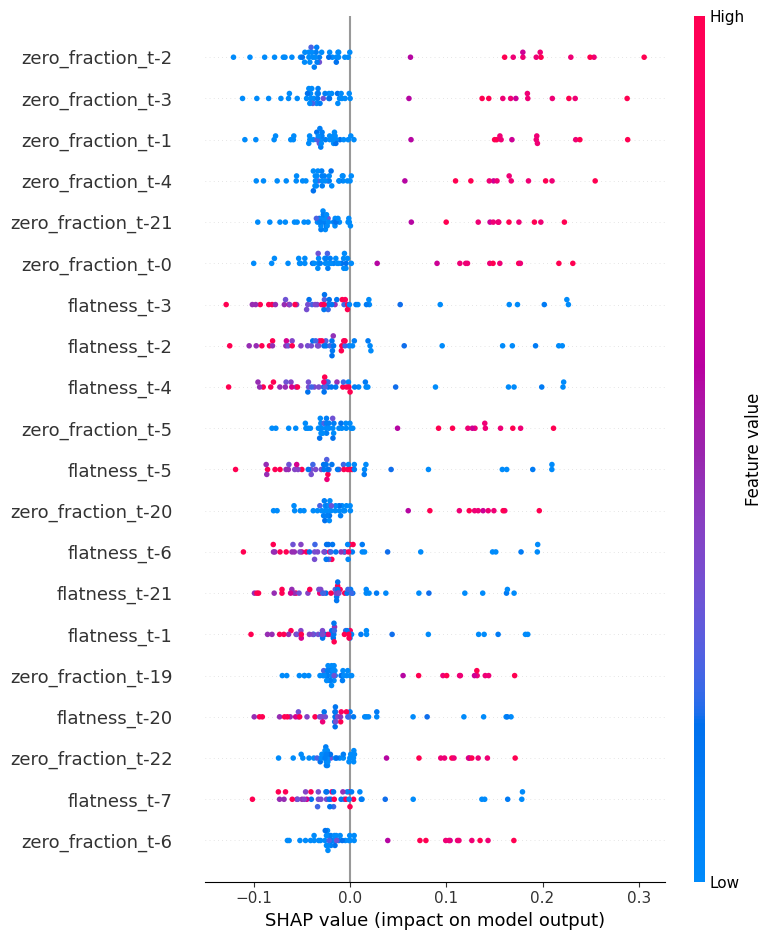

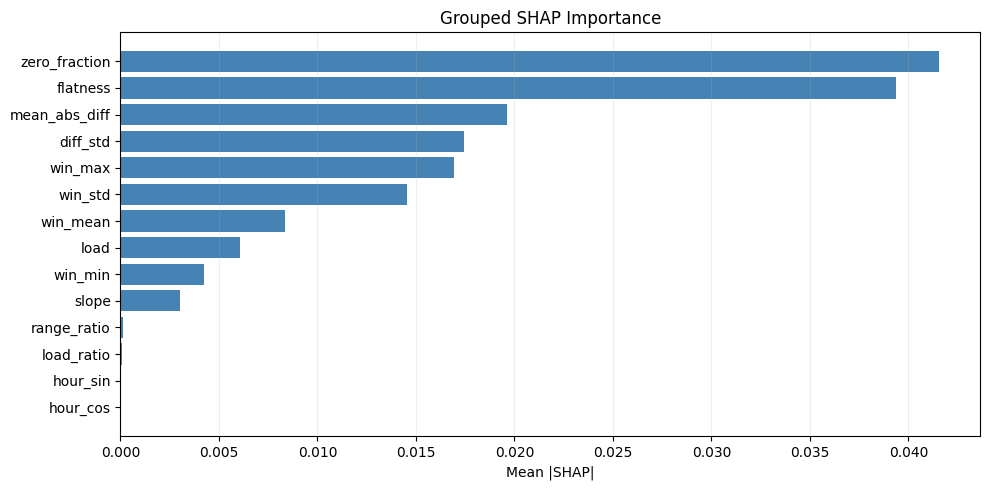

SHAP computed on NVIDIA GeForce RTX 3090 with background=96, test_samples=48, nsamples=32
Top 10 features by mean |SHAP|:
 1. zero_fraction_t-2: 0.07970
 2. zero_fraction_t-3: 0.07283
 3. zero_fraction_t-1: 0.07134
 4. zero_fraction_t-4: 0.06487
 5. zero_fraction_t-21: 0.06209
 6. zero_fraction_t-0: 0.05900
 7. flatness_t-3: 0.05785
 8. flatness_t-2: 0.05684
 9. flatness_t-4: 0.05639
10. zero_fraction_t-5: 0.05475
Top feature groups by mean |SHAP|:
 1. zero_fraction: 0.04156
 2. flatness: 0.03937
 3. mean_abs_diff: 0.01960
 4. diff_std: 0.01746
 5. win_max: 0.01694
 6. win_std: 0.01454
 7. win_mean: 0.00837
 8. load: 0.00604
 9. win_min: 0.00424
10. slope: 0.00302


In [13]:
# GPU-first SHAP explanations for the final model.
model.eval()

class SHAPWrapper(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(self, x):
        return self.base_model(x).unsqueeze(-1)

def balanced_sample_indices(labels, total_size, seed=SEED):
    rng = np.random.default_rng(seed)
    labels = np.asarray(labels)
    positive_idx = np.where(labels == 1)[0]
    negative_idx = np.where(labels == 0)[0]

    selected = []
    take_positive = min(len(positive_idx), total_size // 2)
    take_negative = min(len(negative_idx), total_size - take_positive)

    if take_negative > 0:
        selected.extend(rng.choice(negative_idx, size=take_negative, replace=False).tolist())
    if take_positive > 0:
        selected.extend(rng.choice(positive_idx, size=take_positive, replace=False).tolist())

    if len(selected) < total_size:
        remaining = np.setdiff1d(np.arange(len(labels)), np.array(selected, dtype=int), assume_unique=False)
        if len(remaining) > 0:
            fill = min(total_size - len(selected), len(remaining))
            selected.extend(rng.choice(remaining, size=fill, replace=False).tolist())

    return np.array(sorted(set(selected)), dtype=np.int64)

shap_device = device if USE_GPU else torch.device('cpu')

model_for_shap = TheftDetectionLSTM(**MODEL_CONFIG).to(shap_device)
model_for_shap.load_state_dict(model.state_dict())
model_for_shap.eval()
shap_model = SHAPWrapper(model_for_shap).to(shap_device)
shap_model.eval()

# Keep the SHAP budget meaningful, but small enough to stay GPU-fast.
background_size = min(96, len(X_train_t))
test_size = min(48, len(X_test_t))
shap_nsamples = 32

background_indices = balanced_sample_indices(y_train, background_size, seed=SEED)
test_indices = balanced_sample_indices(y_test, test_size, seed=SEED + 1)

background = X_train_t[background_indices].to(shap_device, non_blocking=PIN_MEMORY)
test_samples = X_test_t[test_indices].to(shap_device, non_blocking=PIN_MEMORY)
subset_true = y_test[test_indices]
subset_preds = all_preds[test_indices]
subset_probs = all_probs[test_indices]

# SHAP on LSTMs is much more stable when cuDNN is disabled for the explainer pass.
cudnn_enabled = torch.backends.cudnn.enabled
torch.backends.cudnn.enabled = False
try:
    explainer = shap.GradientExplainer(shap_model, background)
    raw_shap_values = explainer.shap_values(test_samples, nsamples=shap_nsamples)
finally:
    torch.backends.cudnn.enabled = cudnn_enabled

if isinstance(raw_shap_values, list):
    shap_values = raw_shap_values[0]
else:
    shap_values = raw_shap_values

if isinstance(shap_values, torch.Tensor):
    shap_values = shap_values.detach().cpu().numpy()

shap_values = np.asarray(shap_values)
if shap_values.ndim == 4 and shap_values.shape[-1] == 1:
    shap_values = shap_values[..., 0]

test_np = test_samples.detach().cpu().numpy()
shap_flat = shap_values.reshape(shap_values.shape[0], -1)
test_flat = test_np.reshape(test_np.shape[0], -1)

feature_names = []
for step in range(WINDOW_SIZE):
    time_label = WINDOW_SIZE - 1 - step
    for feature_name in FEATURE_NAMES:
        feature_names.append(f'{feature_name}_t-{time_label}')

mean_abs_shap = np.mean(np.abs(shap_flat), axis=0)
sorted_idx = np.argsort(mean_abs_shap)[::-1]

feature_group_importance = {}
for feature_idx, feature_name in enumerate(FEATURE_NAMES):
    feature_group_importance[feature_name] = float(np.mean(np.abs(shap_flat[:, feature_idx::FEATURE_DIM])))
sorted_groups = sorted(feature_group_importance.items(), key=lambda item: item[1], reverse=True)

plt.figure(figsize=(12, 6))
shap.summary_plot(shap_flat, test_flat, feature_names=feature_names, max_display=20, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 5))
group_labels = [name for name, _ in sorted_groups][::-1]
group_scores = [score for _, score in sorted_groups][::-1]
plt.barh(group_labels, group_scores, color='steelblue')
plt.title('Grouped SHAP Importance')
plt.xlabel('Mean |SHAP|')
plt.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig('shap_group_importance.png', dpi=150, bbox_inches='tight')
plt.show()

device_name = torch.cuda.get_device_name(0) if USE_GPU else 'CPU'
print(f'SHAP computed on {device_name} with background={len(background_indices)}, test_samples={len(test_indices)}, nsamples={shap_nsamples}')
print('Top 10 features by mean |SHAP|:')
for rank in range(min(10, len(sorted_idx))):
    idx = sorted_idx[rank]
    print(f'{rank + 1:>2}. {feature_names[idx]}: {mean_abs_shap[idx]:.5f}')

print('Top feature groups by mean |SHAP|:')
for rank, (name, score) in enumerate(sorted_groups[:10], start=1):
    print(f'{rank:>2}. {name}: {score:.5f}')

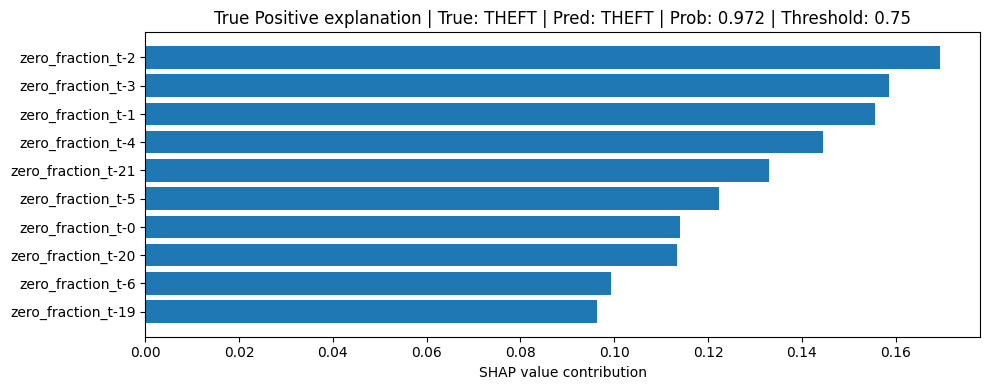

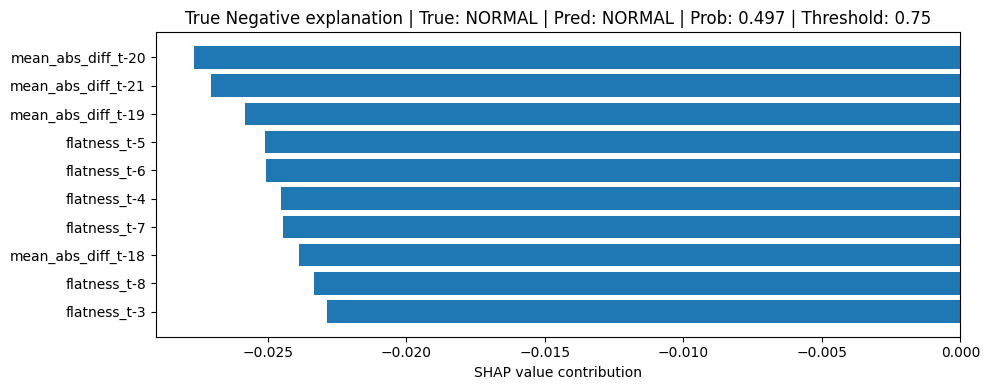

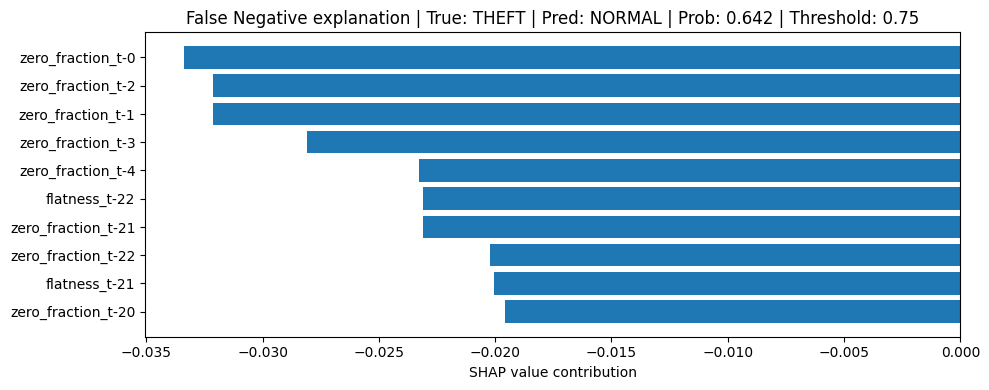

In [14]:
# Local SHAP explanations for representative correctly/incorrectly classified samples.
tp_candidates = np.where((subset_true == 1) & (subset_preds == 1))[0]
tn_candidates = np.where((subset_true == 0) & (subset_preds == 0))[0]
fp_candidates = np.where((subset_true == 0) & (subset_preds == 1))[0]
fn_candidates = np.where((subset_true == 1) & (subset_preds == 0))[0]

selected_examples = []
for label_name, candidates in [
    ('True Positive', tp_candidates),
    ('True Negative', tn_candidates),
    ('False Positive', fp_candidates),
    ('False Negative', fn_candidates),
]:
    if len(candidates) > 0:
        selected_examples.append((label_name, int(candidates[0])))

if not selected_examples:
    selected_examples = [('Sample', 0)]

for plot_id, (label_name, idx) in enumerate(selected_examples[:4]):
    sample_shap = shap_flat[idx]
    top_local = np.argsort(np.abs(sample_shap))[::-1][:10]

    plt.figure(figsize=(10, 4))
    plt.barh([feature_names[i] for i in top_local][::-1], sample_shap[top_local][::-1])
    plt.title(
        f'{label_name} explanation | '
        f'True: {"THEFT" if subset_true[idx] == 1 else "NORMAL"} | '
        f'Pred: {"THEFT" if subset_preds[idx] == 1 else "NORMAL"} | '
        f'Prob: {subset_probs[idx]:.3f} | Threshold: {best_threshold:.2f}'
    )
    plt.xlabel('SHAP value contribution')
    plt.tight_layout()
    plt.savefig(f'shap_local_bar_{plot_id}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Adversarial Robustness Testing (FGSM)

This section measures how performance changes under bounded perturbations and visualizes robustness trends across epsilon levels.

In [17]:
# FGSM adversarial attack helper.
attack_criterion = nn.BCEWithLogitsLoss()
x_clip_min = float(X_train_t.min().item())
x_clip_max = float(X_train_t.max().item())

def fgsm_attack(model, x_batch, y_batch, epsilon=0.05):
    """Generate FGSM adversarial samples for a batch."""
    x_adv = x_batch.clone().detach().to(device)
    y_adv = y_batch.clone().detach().float().to(device)

    x_adv.requires_grad_(True)
    with torch.enable_grad():
        with torch.backends.cudnn.flags(enabled=False):
            logits = model(x_adv)
            loss = attack_criterion(logits, y_adv)
            gradient = torch.autograd.grad(loss, x_adv, retain_graph=False, create_graph=False)[0]

    perturbed = x_adv + epsilon * gradient.sign()
    perturbed = torch.clamp(perturbed, x_clip_min, x_clip_max)
    return perturbed.detach()

In [18]:
# Adversarial robustness test across epsilon values.
epsilon_values = [0.0, 0.01, 0.05, 0.1]
robustness_results = {}

y_true = y_test_t.numpy()

for eps in epsilon_values:
    model.eval()
    adv_preds = []
    adv_probs = []
    adv_logits = []

    for i in range(0, len(X_test_t), EVAL_BATCH_SIZE):
        batch_x = X_test_t[i:i + EVAL_BATCH_SIZE].to(device, non_blocking=PIN_MEMORY)
        batch_y = y_test_t[i:i + EVAL_BATCH_SIZE].to(device, non_blocking=PIN_MEMORY)

        if eps > 0:
            adv_x = fgsm_attack(model, batch_x, batch_y, epsilon=eps)
        else:
            adv_x = batch_x.detach()

        with torch.no_grad():
            adv_logits_batch = model(adv_x)
            adv_probs_batch = torch.sigmoid(adv_logits_batch)
            adv_preds_batch = (adv_probs_batch >= best_threshold).long()

        adv_logits.extend(adv_logits_batch.float().cpu().numpy())
        adv_probs.extend(adv_probs_batch.float().cpu().numpy())
        adv_preds.extend(adv_preds_batch.cpu().numpy())

    adv_preds = np.asarray(adv_preds)
    adv_probs = np.asarray(adv_probs)
    adv_logits = np.asarray(adv_logits)

    precision_a = precision_score(y_true, adv_preds, zero_division=0)
    recall_a = recall_score(y_true, adv_preds, zero_division=0)
    f1_a = f1_score(y_true, adv_preds, zero_division=0)
    balanced_a = balanced_accuracy_score(y_true, adv_preds)
    mcc_a = matthews_corrcoef(y_true, adv_preds)
    fn = int(np.logical_and(y_true == 1, adv_preds == 0).sum())
    tp = int(np.logical_and(y_true == 1, adv_preds == 1).sum())
    fnr_a = fn / max(fn + tp, 1)

    try:
        ap_a = average_precision_score(y_true, adv_probs)
    except ValueError:
        ap_a = 0.0

    robustness_results[eps] = {
        'precision': float(precision_a),
        'recall': float(recall_a),
        'f1': float(f1_a),
        'balanced_accuracy': float(balanced_a),
        'mcc': float(mcc_a),
        'fnr': float(fnr_a),
        'ap': float(ap_a),
    }

print('\nAdversarial Robustness Results:')
print(f'{"Epsilon":<10} {"Precision":<12} {"Recall":<12} {"F1-Score":<12} {"BAcc":<12} {"FNR":<10} {"AP":<12}')
print('-' * 84)
for eps, metrics in robustness_results.items():
    print(
        f'{eps:<10.2f} {metrics["precision"]:<12.4f} '
        f'{metrics["recall"]:<12.4f} {metrics["f1"]:<12.4f} '
        f'{metrics["balanced_accuracy"]:<12.4f} {metrics["fnr"]:<10.4f} {metrics["ap"]:<12.4f}'
    )


Adversarial Robustness Results:
Epsilon    Precision    Recall       F1-Score     BAcc         FNR        AP          
------------------------------------------------------------------------------------
0.00       0.9428       0.6108       0.7413       0.8034       0.3892     0.7443      
0.01       0.7139       0.5417       0.6160       0.7588       0.4583     0.6425      
0.05       0.2289       0.3150       0.2651       0.5985       0.6850     0.2780      
0.10       0.1656       0.3013       0.2137       0.5663       0.6987     0.1880      


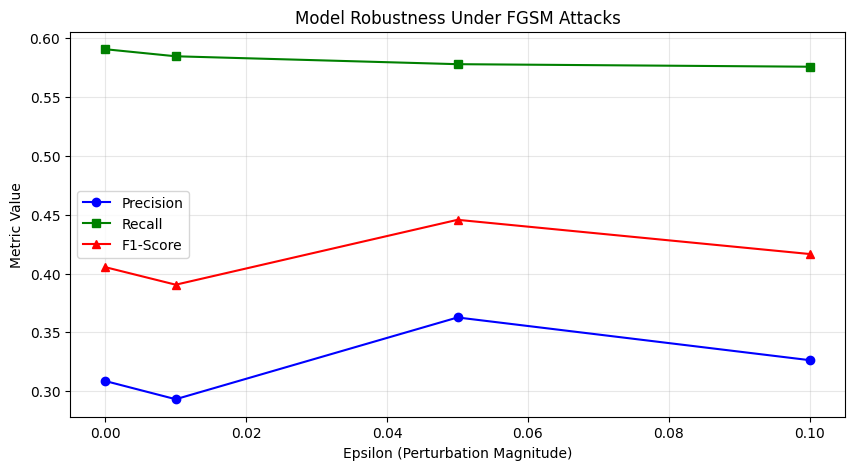

In [19]:
eps_list = list(robustness_results.keys())
precisions = [robustness_results[e]['precision'] for e in eps_list]
recalls = [robustness_results[e]['recall'] for e in eps_list]
f1s = [robustness_results[e]['f1'] for e in eps_list]

plt.figure(figsize=(10, 5))
plt.plot(eps_list, precisions, 'o-', label='Precision', color='blue')
plt.plot(eps_list, recalls, 's-', label='Recall', color='green')
plt.plot(eps_list, f1s, '^-', label='F1-Score', color='red')
plt.xlabel('Epsilon (Perturbation Magnitude)')
plt.ylabel('Metric Value')
plt.title('Model Robustness Under FGSM Attacks')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('adversarial_robustness.png', dpi=150, bbox_inches='tight')
plt.show()


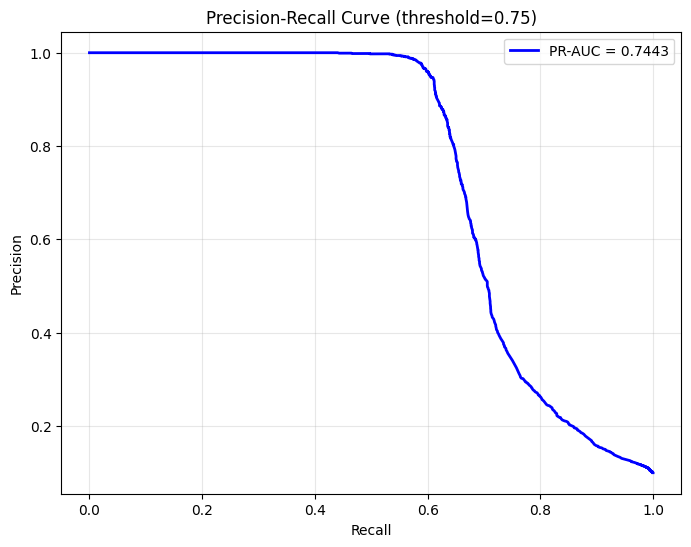

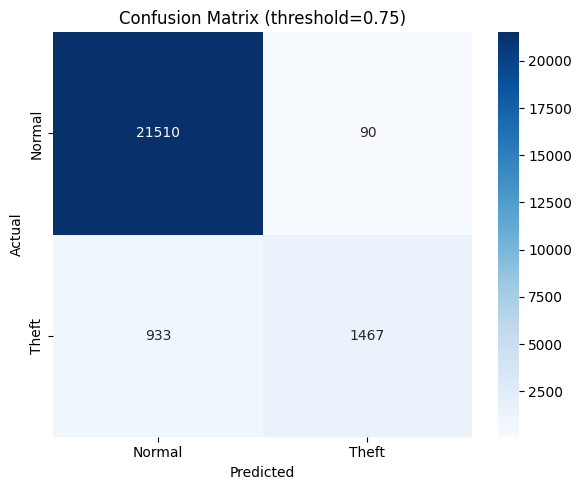

Confusion Matrix:
[[21510    90]
 [  933  1467]]


In [20]:
# Precision-Recall curve and confusion matrix.
precisions_curve, recalls_curve, _ = precision_recall_curve(y_true, all_probs)
pr_auc = auc(recalls_curve, precisions_curve)

plt.figure(figsize=(8, 6))
plt.plot(recalls_curve, precisions_curve, label=f'PR-AUC = {pr_auc:.4f}', color='blue', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (threshold={best_threshold:.2f})')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

cm = confusion_matrix(y_true, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Theft'],
    yticklabels=['Normal', 'Theft']
    )
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (threshold={best_threshold:.2f})')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Confusion Matrix:\n{cm}')

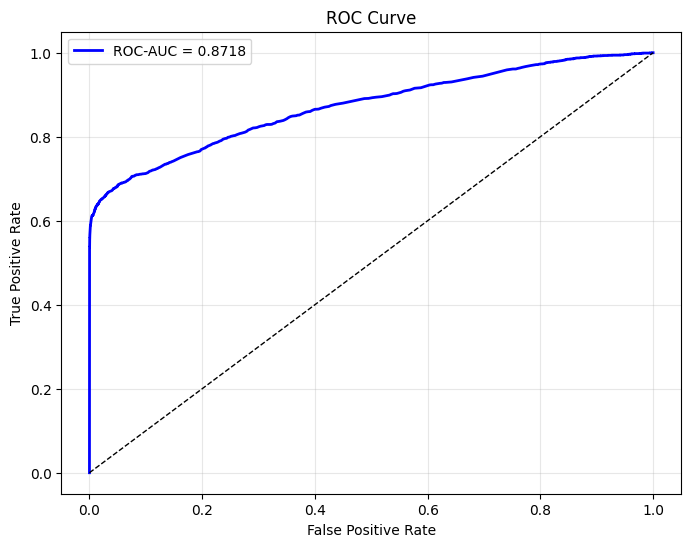

In [21]:
# ROC Curve.
fpr, tpr, _ = roc_curve(y_true, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.4f}', color='blue', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
print('=' * 60)
print('FINAL RESULTS SUMMARY')
print('=' * 60)

print('\n1. Validation-Selected Decision Rule:')
print(f'   Best threshold: {best_threshold:.2f}')
print(f'   Best validation F1: {best_threshold_metrics.get("f1", float("nan")):.4f}')
print(f'   Best validation precision: {best_threshold_metrics.get("precision", float("nan")):.4f}')
print(f'   Best validation recall: {best_threshold_metrics.get("recall", float("nan")):.4f}')

print('\n2. Test Performance:')
print(f'   Precision: {test_metrics["precision"]:.4f}')
print(f'   Recall:    {test_metrics["recall"]:.4f}')
print(f'   F1-Score:  {test_metrics["f1"]:.4f}')
print(f'   Balanced Accuracy: {test_metrics["balanced_accuracy"]:.4f}')
print(f'   MCC:      {test_metrics["mcc"]:.4f}')
print(f'   PR-AUC:   {test_metrics["pr_auc"]:.4f}')
print(f'   ROC-AUC:  {test_metrics["roc_auc"]:.4f}')

print('\n3. Robustness Under FGSM:')
for eps in [0.0, 0.01, 0.05, 0.10]:
    metrics = robustness_results[eps]
    drop = robustness_results[0.0]['f1'] - metrics['f1']
    print(
        f'   Epsilon={eps:.2f}: F1={metrics["f1"]:.4f}, '
        f'Precision={metrics["precision"]:.4f}, Recall={metrics["recall"]:.4f}, '
        f'F1-Drop={drop:.4f}'
    )

print('\n4. Explainability Outputs:')
print('   SHAP summary: shap_summary.png')
print('   SHAP grouped importance: shap_group_importance.png')
print('   Local SHAP plots: shap_local_bar_*.png')
print('=' * 60)

FINAL RESULTS SUMMARY

1. Validation-Selected Decision Rule:
   Best threshold: 0.75
   Best validation F1: 0.7710
   Best validation precision: 0.9545
   Best validation recall: 0.6467

2. Test Performance:
   Precision: 0.9422
   Recall:    0.6112
   F1-Score:  0.7415
   Balanced Accuracy: 0.8035
   MCC:      0.7394
   PR-AUC:   0.7443
   ROC-AUC:  0.8718

3. Robustness Under FGSM:
   Epsilon=0.00: F1=0.7413, Precision=0.9428, Recall=0.6108, F1-Drop=0.0000
   Epsilon=0.01: F1=0.6160, Precision=0.7139, Recall=0.5417, F1-Drop=0.1254
   Epsilon=0.05: F1=0.2651, Precision=0.2289, Recall=0.3150, F1-Drop=0.4762
   Epsilon=0.10: F1=0.2137, Precision=0.1656, Recall=0.3013, F1-Drop=0.5276

4. Explainability Outputs:
   SHAP summary: shap_summary.png
   SHAP grouped importance: shap_group_importance.png
   Local SHAP plots: shap_local_bar_*.png


In [23]:
import json

def jsonable(value):
    if isinstance(value, (np.floating, np.integer)):
        return value.item()
    return value

# Export metrics to JSON for report population.
baseline = robustness_results.get(0.0, {})

results = {
    'best_threshold': float(best_threshold),
    'validation_metrics': {
        key: jsonable(value)
        for key, value in best_threshold_metrics.items()
    },
    'test_metrics': {
        key: jsonable(value)
        for key, value in test_metrics.items()
    },
    'robustness_under_attack': {
        str(epsilon): {metric: jsonable(value) for metric, value in metrics.items()}
        for epsilon, metrics in robustness_results.items()
    },
    'feature_group_importance': {name: float(score) for name, score in feature_group_importance.items()},
    'confusion_matrix': cm.tolist(),
    'pr_auc': float(pr_auc),
    'roc_auc': float(roc_auc),
    'brier_score': float(test_metrics['brier']),
    'log_loss': float(test_metrics['logloss']),
}

with open('results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))
print('\nResults exported to results.json')

{
  "best_threshold": 0.7499999999999999,
  "validation_metrics": {
    "threshold": 0.7499999999999999,
    "precision": 0.9544895448954489,
    "recall": 0.6466666666666666,
    "f1": 0.7709885742672627,
    "balanced_accuracy": 0.8216205289633676,
    "mcc": 0.7678473008273503
  },
  "test_metrics": {
    "precision": 0.9421965317919075,
    "recall": 0.61125,
    "f1": 0.7414708112206216,
    "balanced_accuracy": 0.8035416666666666,
    "mcc": 0.7394282612625832,
    "cohen_kappa": 0.7193877551020409,
    "test_loss": 0.04110144074757894,
    "threshold": 0.7499999999999999,
    "brier": 0.24755802750587463,
    "logloss": 0.678635684329065,
    "pr_auc": 0.7443046119168805,
    "roc_auc": 0.8718097993827161
  },
  "robustness_under_attack": {
    "0.0": {
      "precision": 0.9427652733118971,
      "recall": 0.6108333333333333,
      "f1": 0.7413400758533502,
      "balanced_accuracy": 0.8033564814814815,
      "mcc": 0.7394192776325024,
      "fnr": 0.38916666666666666,
      "a